# Sensor Directed Sampling - AJ's Mod.

<div style="color: red;">Note: at the moment the SDS only supports 2 components. Please select 2 PCS when designing</div>

In [ ]:
# @title Run this Cell and then wait for the upload prompts to appear.

print("setting up environment")
!pip install -q pyDOE3 pykrige pysal
!rm -rf sample_data

print("\nimporting libraries")

import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances

from scipy.stats import trim_mean, trimboth
from scipy.spatial import KDTree
from scipy.spatial import distance, distance_matrix
from scipy.spatial.distance import pdist

from shapely.geometry import Point
from pyDOE3 import ccdesign
from pykrige.ok import OrdinaryKriging
import pysal.lib
from esda.moran import Moran, Moran_BV_matrix
from libpysal.weights import DistanceBand, KNN

import random
from tqdm.auto import tqdm
from itertools import combinations
from functools import lru_cache

import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files

random.seed(42)

# --- Upload File 1 ---
print("\nPlease upload your first data file (Excel or CSV). This supports large files.")
uploaded1 = files.upload()

file1_name = next(iter(uploaded1))
with open(file1_name, "wb") as f:
    f.write(uploaded1[file1_name])
print(f"Done. File '{file1_name}' has been saved in /content/.")

# --- Optional Upload File 2 ---
print("\nIf you want to upload a second file, type 'y' and press Enter, otherwise just press Enter to skip.")
choice = input("Upload a second file? [y/N]: ").strip().lower()

file2_name = None
if choice == "y":
    uploaded2 = files.upload()
    file2_name = next(iter(uploaded2))
    with open(file2_name, "wb") as f:
        f.write(uploaded2[file2_name])
    print(f"Done. File '{file2_name}' has been saved in /content/.")
else:
    print("Skipping second file upload.")

# --- Reminder ---
print("\n✅ All done.")


setting up environment

importing libraries

Please upload your first data file (Excel or CSV). This supports large files.


Saving ndvi_ndre_merged_utm.csv to ndvi_ndre_merged_utm.csv
Done. File 'ndvi_ndre_merged_utm.csv' has been saved in /content/.

If you want to upload a second file, type 'y' and press Enter, otherwise just press Enter to skip.
Upload a second file? [y/N]: 
Skipping second file upload.

✅ All done.


In [ ]:
# @title Enter target locations that you already have and will be considered during evaluation.

_infer_lat = []
_infer_lon = []
_infer_idx = []
_lat_lon_box = []

new_infer_lat = lambda: widgets.FloatText(description='Enter lat:', disabled=False)
new_infer_lon = lambda: widgets.FloatText(description='Enter lon:', disabled=False)
new_infer_idx = lambda: widgets.IntText(description='Enter Idx:', disabled=False)

def update_display():
    clear_output(wait=True)
    display(widgets.VBox(_lat_lon_box))
    display(add_btn)

def x_btn_click(b, lat_widget, lon_widget, idx_widget):
    index = next((i for i, hbox in enumerate(_lat_lon_box) if lat_widget in hbox.children and lon_widget in hbox.children and idx_widget in hbox.children), None)
    if index is not None:
        _lat_lon_box.pop(index)
        _infer_lon.pop(index)
        _infer_lat.pop(index)
        _infer_idx.pop(index)
        update_display()

def new_button(lat_widget, lon_widget, idx_widget):
    button = widgets.Button(
        description='X',
        disabled=False,
        button_style='',
        tooltip='X',
        icon='square',
        layout={'width':'35px'}
    )
    button.on_click(lambda b: x_btn_click(b, lat_widget, lon_widget, idx_widget))
    return button

add_btn = widgets.Button(
    description=' + ',
    disabled=False,
    button_style='',
    layout={'width':'35px'},
    tooltip='add design',
    icon='check'
)

def add_new_target(b):
    lat_widget = new_infer_lat()
    lon_widget = new_infer_lon()
    idx_widget = new_infer_idx()
    _infer_lat.append(lat_widget)
    _infer_lon.append(lon_widget)
    _infer_idx.append(idx_widget)
    _lat_lon_box.append(widgets.HBox([lat_widget, lon_widget, idx_widget, new_button(lat_widget, lon_widget, idx_widget)]))
    update_display()

add_btn.on_click(add_new_target)
update_display()

VBox()

Button(description=' + ', icon='check', layout=Layout(width='35px'), style=ButtonStyle(), tooltip='add design'…

In [ ]:
# @title View first data file

# Try reading as CSV first
try:
    df = pd.read_csv(file1_name)
    print("Loaded as CSV.")
except Exception as e_csv:
    print(f"Could not load as CSV: {e_csv}")
    # Try Excel
    try:
        df = pd.read_excel(file1_name)
        print("Loaded as Excel.")
    except Exception as e_excel:
        print(f"Could not load as Excel either: {e_excel}")
        df = None

if df is not None:
    display(df.sample(5))
else:
    print("Could not load the file. Check the format.")


Loaded as CSV.


,Unnamed: 0,pointid,NDVI,NDRE,lat,long,geometry,easting,northing
44307,44307,44308,0.859869,0.238434,-106.921216,40.200145,POINT (336480.2044575926 4451741.681314101),336480.204458,4.451742e+06
226223,226223,226224,0.867442,0.286064,-106.916265,40.193309,POINT (336885.2022429073 4450973.681755629),336885.202243,4.450974e+06
181543,181543,181544,0.880432,0.289760,-106.915685,40.195228,POINT (336939.2090374129 4451185.6814452),336939.209037,4.451186e+06
199705,199705,199706,0.828682,0.267153,-106.916230,40.194570,POINT (336891.2060013126 4451113.681714411),336891.206001,4.451114e+06
76265,76265,76266,0.878469,0.286913,-106.920475,40.198869,POINT (336540.2030540738 4451598.682077774),336540.203054,4.451599e+06


In [ ]:
#@title Select UTM zone

epsg_code = None

utm_zone_number = widgets.Dropdown(
    options=list(range(1, 61)),
    value=13,
    description='UTM Zone:',
)
# Dropdown for the hemisphere part of the UTM zone (N/S)
utm_zone_hemisphere = widgets.Dropdown(
    options=['N', 'S'],
    value='N',
    description='Hemisphere:',
)

# Function to display the appropriate EPSG code based on the UTM zone number and hemisphere
def display_epsg_code(zone_number, hemisphere):
    global epsg_code
    # Northern hemisphere zones are in the EPSG range 32601 to 32660
    # Southern hemisphere zones are in the EPSG range 32701 to 32760
    if hemisphere == 'N':
        epsg_code = 32600 + zone_number
    else:
        epsg_code = 32700 + zone_number
    print(f"EPSG Code for UTM Zone {zone_number} {hemisphere}: {epsg_code}")

# Display the dropdown menus
hbox2 = widgets.HBox([utm_zone_number, utm_zone_hemisphere])
# Use interactive or interactive_output to dynamically display the EPSG code
output_zone = widgets.interactive_output(display_epsg_code, {'zone_number': utm_zone_number, 'hemisphere': utm_zone_hemisphere})
display(hbox2, output_zone)


Output()

In [ ]:
# @title Select the IDx column
# @markdown select the column used for ID for sensor data, by default, the code will try to add a column with row number to be used as ID
FID = widgets.Dropdown(
    options=['add an ID column']+df.columns.tolist(),
    value='add an ID column',
    description='Sample ID (optional)',
    disabled=False,
    style={'description_width': 'initial'}
)
display(FID)

Dropdown(description='Sample ID (optional)', options=('add an ID column', 'Unnamed: 0', 'pointid', 'NDVI', 'ND…

In [ ]:
# @title select latitude and longitude from the features
prefered_lat = [i.value for i in _infer_lat]
prefered_lon = [i.value for i in _infer_lon]
prefered_idx = [i.value for i in _infer_idx]

lat = widgets.Dropdown(
    options=df.columns,
    value=df.columns[0],
    description='Latitude:',
    disabled=False,
)

lon = widgets.Dropdown(
    options=df.columns,
    value=df.columns[1],
    description='Longitude:',
    disabled=False,
)

def plot_change(change_lat, change_lon):
    # clear_output(wait=True)
    # display(lat)
    # display(lon)
    plt.clf()
    try:
        assert lat.value != lon.value, "select different Lat and Lon columns above"
        plt.scatter(df[lon.value], df[lat.value])
        plt.title('Geo space')
        plt.xlabel(lat.value)
        plt.ylabel(lon.value)
        plt.tight_layout()
    except AssertionError as e:
        print(e.args[0])
        sns.histplot(data=df[lat.value])
        plt.xlabel(lat.value)
        plt.ylabel('Density')
        plt.title(f'histogram of {lat.value}')
        plt.tight_layout()
    plt.show()

# display(lat, lon)
# lat.observe(plot_change)
# lon.observe(plot_change)
# plot_change(0)

interactive_plot = widgets.interactive_output(plot_change, {'change_lat': lat, 'change_lon' : lon})
display(lat, lon, interactive_plot)

Dropdown(description='Latitude:', options=('Unnamed: 0', 'pointid', 'NDVI', 'NDRE', 'lat', 'long', 'geometry',…

Dropdown(description='Longitude:', index=1, options=('Unnamed: 0', 'pointid', 'NDVI', 'NDRE', 'lat', 'long', '…

Output()

In [ ]:
# @title Select the features for variable space
checkboxes = []
for col in df.columns:
    if col not in [lat.value, lon.value]:
        checkboxes.append(widgets.Checkbox(
        value=True,
        description=col,
        disabled=False,
        indent=False
        ))
        display(checkboxes[-1])

Checkbox(value=True, description='Unnamed: 0', indent=False)

Checkbox(value=True, description='pointid', indent=False)

Checkbox(value=True, description='NDVI', indent=False)

Checkbox(value=True, description='NDRE', indent=False)

Checkbox(value=True, description='lat', indent=False)

Checkbox(value=True, description='long', indent=False)

Checkbox(value=True, description='geometry', indent=False)

In [ ]:
# @title Select the Scaling scheme for the above selected features:
# @markdown regardless of the selected scaling method, the data will be normalized.
# @markdown > RobustScaler is Robust to outliers <br>
# @markdown > StandardScaler is only normalizing the features<br>
# @markdown > PowerTransformer will transform data to gaussian like spread in variable space
mask = [i.value for i in checkboxes]

selected_df = df.loc[:, df.columns.drop(lat.value).drop(lon.value)[mask]]

geometry = [Point(xy) for xy in df.loc[:,[lat.value,lon.value]].values]
gdf = gpd.GeoDataFrame(selected_df, geometry=geometry)
gdf.crs = f"EPSG:{epsg_code}"

scalar_scheme = widgets.RadioButtons(
    options=['RobustScaler', 'StandardScaler', 'PowerTransformer'],
    value='StandardScaler', # Defaults to 'StandardScaler'
#    layout={'width': 'max-content'}, # If the items' names are long
    description='Scaling scheme',
    disabled=False,
    style={'description_width': 'initial'}
)
display(scalar_scheme)

RadioButtons(description='Scaling scheme', index=1, options=('RobustScaler', 'StandardScaler', 'PowerTransform…

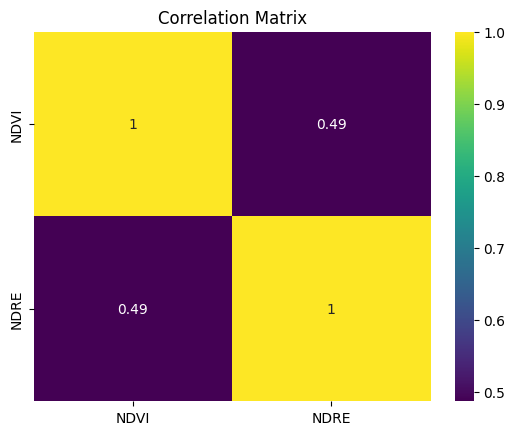

In [ ]:
#@title Heatmap of correlation matrix of Selected features
variables = selected_df.columns
locations = df.loc[:,[lat.value, lon.value]].values

#distance_band = DistanceBand.from_array(locations, threshold=20, binary=True, silence_warnings=True)
#knn_weights = KNN.from_array(locations, k=10, silence_warnings=True)

# weights = distance_band

# MBV_mat = Moran_BV_matrix(selected_df, w=weights, varnames=variables)
# Moran_I = np.zeros((selected_df.shape[1], selected_df.shape[1]), dtype=np.float64)

# for (i,j),v in MBV_mat.items():
#     Moran_I[i,j] = v.I
# for i,e in enumerate(selected_df.columns):
#     Moran_I[i,i] = Moran(selected_df[e], weights).I

# Visualize the Moran's I matrix as a heatmap
# sns.heatmap(Moran_I, annot=True, xticklabels=variables, yticklabels=variables, cmap='coolwarm', center=0)
# plt.title("Bivariate Moran's I Matrix")
# plt.show()

sns.heatmap(selected_df.corr(), annot=True, cmap='viridis')  # 'annot' adds numbers on the cells, 'cmap' changes the color map
plt.title('Correlation Matrix')  # Add a title to the heatmap
plt.show()

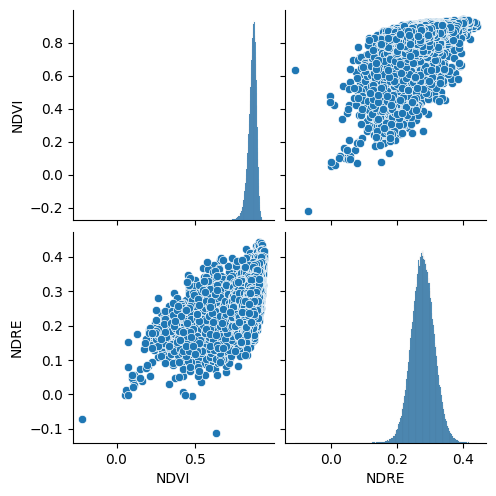

In [ ]:
#@title pairplot of corelation matrix of Selected features (optional)
#@markdown this takes a lot of time. you can skip this if you dont want to see the pair plots
sns.pairplot(selected_df)


In [ ]:
# @title select number of principal components to keep:
scaler = {
    'RobustScaler'     : RobustScaler(),
    'StandardScaler'   : StandardScaler(),
    'PowerTransformer' : PowerTransformer()
    }[scalar_scheme.value]

X_scaled = scaler.fit_transform(selected_df.values)

# Apply PCA
pca = PCA(n_components=X_scaled.shape[1])
X_pca = pca.fit_transform(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cdf = pd.DataFrame(np.multiply(cumulative_variance, 100).round(3).reshape(1,-1).tolist(), columns=list(range(1,len(cumulative_variance)+1)), index=["% cumulative variance captured :"])

print("number of Principal Components:")
display(cdf)
print('\n\n')
pca_selector = widgets.IntSlider(
    value=2,
    min=1,
    max=len(cumulative_variance),
    step=1,
    description='',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)
display(pca_selector)

number of Principal Components:


,1,2
% cumulative variance captured :,74.37,100.0


IntSlider(value=2, continuous_update=False, max=2, min=1)

In [ ]:
# @title Select threshold to filter out the values

whitten = widgets.IntSlider(value=5, min=0, max=100,step=1,description='Scaling factor (%) :',disabled=False,continuous_update=False,orientation='horizontal',readout=True,readout_format='.1f',style={'description_width': 'initial'})
threshold = widgets.FloatSlider(value=1.2, min=0, max=3,step=0.1,description='Outlier threshold :',disabled=False,continuous_update=False,orientation='horizontal',readout=True,readout_format='.1f',style={'description_width': 'initial'})
sampling = widgets.SelectionSlider(options=[5,10,12,15,20],value=20,description='No of design points: ',disabled=False,continuous_update=False,orientation='horizontal',readout=True,style={'description_width': 'initial'})
lines_select = widgets.SelectMultiple(options=['All Points', 'Outliers', 'Selected Points', 'Target Points', 'given preffered points', 'Shortlisted Points'], value=['All Points', 'Outliers', 'Selected Points', 'Target Points', 'given preffered points', 'Shortlisted Points'], description='Plots: select multiple by holding down ctrl/cmd + click', disabled=False)

def generate_design(data, n_samples, whitten=0):
    ccd = ccdesign(2, center=(1,1), alpha='o', face='cci')
    scaled_ccd = np.zeros_like(ccd) # Initialize scaled CCD with the correct shape
    ccd_min, ccd_max = ccd.min(axis=0), ccd.max(axis=0) # Compute scaling parameters
    data_min, data_max = np.percentile(data, [whitten, 100-whitten], axis=0)
    scaled_ccd = (ccd - ccd_min) / (ccd_max - ccd_min) * (data_max - data_min) + data_min # Scale design
    # Extract subsets
    ccd_boxes = scaled_ccd[:4]
    ccd_star = scaled_ccd[5:9]
    support_points = lambda x: np.repeat(scaled_ccd[np.newaxis, 4, :], x, axis=0) # Support points generator
    # Define the designs list with optimized operations
    designs = [
        np.vstack([ccd_boxes, support_points(1)]),
        np.vstack([ccd_star, support_points(1)]),
    ]
    # Additional designs based on manipulation of existing ones
    designs += [designs[1][:2] / 2, designs[1][2:] / 2, designs[0] / 2]
    # Determine the design closest to the target number of samples
    al_list = np.cumsum([len(d) for d in designs])
    k = np.searchsorted(al_list, n_samples)
    # Concatenate the selected designs up to the closest match
    return np.vstack(designs[:k+1]), al_list.tolist()

pca = PCA(n_components=pca_selector.value)
PCs = pca.fit_transform(X_scaled)
rows_to_keep = np.ones(PCs.shape[0], dtype=bool)
filtered_Pcs = PCs[:,:]
preferedPCs = None
filtered_distances = None
filtered_indices = None
Geo_space_XY = None
Var_space_XY = None
epsilion = 1e-7# change this
NNearest_neighbour = 3 # change this

allowed_samples = [5, 10, 12, 15, 20, 24] # change this as needed
sampling.options = allowed_samples
no_of_samples = 20
sampling.value = no_of_samples
design = generate_design(filtered_Pcs, sampling.value , whitten.value)



def plot_onchange(threshold, sampling, whitten, plots):
    global design
    global PCs
    global preferedPCs
    global filtered_Pcs
    global filtered_distances
    global filtered_indices
    global no_of_samples
    global rows_to_keep
    global Geo_space_XY
    global Var_space_XY
    global epsilion
    global NNearest_neighbour

    _threshold = threshold # t times the IQR
    no_of_samples = sampling

    Q1, Q3 = np.percentile(PCs, [25, 75], axis=0) # Calculate Q1 and Q3
    IQR = Q3 - Q1 # Calculate the IQR
    # Determine outlier bounds for each feature
    lower_bounds = (Q1 - _threshold * IQR).reshape(1, -1)
    upper_bounds = (Q3 + _threshold * IQR).reshape(1, -1)
    within_bounds = (PCs >= lower_bounds) & (PCs <= upper_bounds)
    rows_to_keep = np.all(within_bounds, axis=1)

    filtered_Pcs = PCs[rows_to_keep] # Convert filtered_data list to a NumPy array
    outliers_Pcs = PCs[~rows_to_keep] # Convert filtered_data list to a NumPy array
    design, _ = generate_design(filtered_Pcs, no_of_samples, whitten)

    Geo_space_X = df.loc[rows_to_keep, lat.value]
    Geo_space_Y = df.loc[rows_to_keep, lon.value]
    Geo_space_XY = np.array([Geo_space_X, Geo_space_Y]).T
    Var_space_XY = filtered_Pcs
    # -----------------------------
    # Replace memory-intensive distance calculation
    # -----------------------------
    # Old methods (kept for reference):
    # from scipy.spatial.distance import distance_matrix, pdist
    # max_dist = np.max(distance_matrix(Geo_space_XY, Geo_space_XY))
    # max_dist = np.max(pdist(Geo_space_XY))

    # New efficient method using KDTree (O(n log n) memory and time)
    tree_geo = KDTree(Geo_space_XY)
    _, neighbor_dists = tree_geo.query(Geo_space_XY, k=2)  # k=2 to skip self (distance = 0)
    max_dist = np.max(neighbor_dists[:, 1])  # max distance to nearest neighbor
    geo_max = max_dist
    geo_min = 0 + epsilion
    var_max = .25 # change this
    var_min = 0 + epsilion

    # inference target points
    if prefered_lon:
        preferedPCs = []
        kriging_models = [OrdinaryKriging(Geo_space_Y, Geo_space_X, Var_space_XY[:, i], variogram_model='spherical') for i in range(PCs.shape[1])]
        for kriging_model in kriging_models:
            predicted_value, predicted_std = kriging_model.execute('points', prefered_lon, prefered_lat)
            preferedPCs.append(predicted_value.data)
        preferedPCs = np.vstack(preferedPCs).T

    tree = KDTree(Var_space_XY)
    distances, indices = tree.query(design, k=NNearest_neighbour)
    ind_ko = np.unique(indices)

    # Filter based on valid_indices
    valid_indices = distances < var_max
    filtered_distances = [distances[i][valid_i] for i, valid_i in enumerate(valid_indices)]
    filtered_indices = [indices[i][valid_i] for i, valid_i in enumerate(valid_indices)]
    ind_ko = np.unique(indices[valid_indices])
    avg = np.average(distances, axis=1)
    if (np.min(distances, axis=1) > var_max).any():
        print("Error: scaled design does not fit in varibale scale, please refer to graph to fit the design properly")
    elif (avg > var_max).any():
        print('''warning: scaled design is not a good fit in varibale scale,
                 kindly readjust the thresholds and try again for better fit
                 or try using a different scaler to change the distribution''')

    # finding unique ind across all design points
    assigned_to = {}  # Tracks which design point an index is assigned to
    point_counts = np.zeros(len(design), dtype=int)  # Tracks how many points are assigned to each design point

    for i in range(len(design)):
        for j in range(NNearest_neighbour):
            if not valid_indices[i][j]:
                break
            idx = indices[i][j]
            dist = distances[i][j]
            # Check if the index is already assigned
            if idx in assigned_to:
                # Retrieve previously assigned design point and distance
                prev_i, prev_dist = assigned_to[idx]
                if dist < prev_dist or (dist == prev_dist and point_counts[i] < point_counts[prev_i]):
                    # Update assignment if current design point is closer or equally close but has fewer points
                    point_counts[prev_i] -= 1
                    point_counts[i] += 1
                    assigned_to[idx] = (i, dist)
            else:
                # Assign index to the current design point
                assigned_to[idx] = (i, dist)
                point_counts[i] += 1
    # Construct the final list of assigned indices for each design point
    assigned_indices = [[] for _ in range(len(design))]
    for idx, (i, _) in assigned_to.items():
        assigned_indices[i].append(idx)
    # Optionally, convert each list of indices to a NumPy array
    assigned_indices = [np.array(lst) for lst in assigned_indices]
    filtered_indices = assigned_indices

    plt.clf()
    plt.figure(figsize=(8,10))
    if 'All Points' in plots:
        plt.scatter(PCs[:,0], PCs[:,1], s=10, c="cyan", label='All Points')
    if 'Outliers' in plots:
        plt.scatter(outliers_Pcs[:,0], outliers_Pcs[:,1], s=10, c="blue", label="Outliers")
    if 'Selected Points' in plots:
        plt.scatter(filtered_Pcs[:,0], filtered_Pcs[:,1], s=10, c="yellow", label="Selected Points")
    if 'Target Points' in plots:
        plt.scatter(design[:,0], design[:,1], marker="+", c="black", s=50, label="Target Points")
        radius = .3
        theta = np.linspace(0, 2 * np.pi, 100) # Create an array of angles from 0 to 2pi
        x_coords = design[:, 0, np.newaxis] + radius * np.cos(theta)
        y_coords = design[:, 1, np.newaxis] + radius * np.sin(theta)
        for x, y, ed_indi in zip(x_coords, y_coords, assigned_indices):
            plt.plot(x, y, 'y:' if len(ed_indi) else 'r-')
    if 'given preffered points' in plots and prefered_lon:
        plt.scatter(*preferedPCs.T, c="magenta", s=20, label="given preffered points" )
        # Annotating each point
        for i, (x, y) in enumerate(preferedPCs):
            plt.annotate(prefered_idx[i], (x, y+.06))
    if 'Shortlisted Points' in plots:
        plt.scatter(filtered_Pcs[ind_ko,0], filtered_Pcs[ind_ko,1], s=10, c="green", label="Shortlisted Points")

    plt.title('Variable Space')
    plt.legend()
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.tight_layout()
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

    print("Original Data Shape:", PCs.shape)
    print("Filtered Data Shape:", filtered_Pcs.shape)
    print("Percentage of Data Retained:", f"{filtered_Pcs.shape[0]/PCs.shape[0]*100:.2f}%")


# Create a Label widget for the text
text_label = widgets.Label(' times IQR')
hbox = widgets.HBox([threshold, text_label]) # Arrange the slider and the text label horizontally
interactive_plot = widgets.interactive_output(plot_onchange, {'threshold':threshold, 'whitten': whitten, 'sampling' : sampling, 'plots': lines_select})
display(hbox, whitten, sampling, lines_select, interactive_plot)

IntSlider(value=5, continuous_update=False, description='Scaling factor (%) :', readout_format='.1f', style=Sl…

SelectionSlider(continuous_update=False, description='No of design points: ', index=4, options=(5, 10, 12, 15,…

SelectMultiple(description='Plots: select multiple by holding down ctrl/cmd + click', index=(0, 1, 2, 3, 4, 5)…

Output()

In [ ]:
# @title inferencing Preferred locations
# @markdown - only location inside the threshold circle will be used
# @markdown - run this cell even if you don't have preferred points

from scipy.spatial import KDTree  # Make sure this is imported

# Scale functions
scale_geo = lambda x: (x - geo_min) / (geo_max - geo_min) * 3
scale_var = lambda x: (x - var_min) / (var_max - var_min) * 3

# Calculate spatial distance bounds
tree_geo = KDTree(Geo_space_XY)
dists_geo, _ = tree_geo.query(Geo_space_XY, k=2)  # k=2 includes self + nearest
geo_max = np.nanmax(dists_geo[:, 1])  # skip self-distance
geo_min = np.nanmin(dists_geo[:, 1]) + epsilion

# Variance bounds (fixed or calculated if needed)
var_max = 0.4
var_min = 0 + epsilion

# Efficiently compute distances from each design point to its assigned filtered_indices
filtered_distances = []
for i, e in enumerate(filtered_indices):
    if len(e) == 0:
        filtered_distances.append(np.array([]))
        continue
    distances = np.linalg.norm(design[i] - Var_space_XY[e], axis=1)
    filtered_distances.append(distances)

# Handle preferred points (optional)
if prefered_lat:
    x = distance_matrix(design, preferedPCs)
    prefered_mask = (x < var_max).any(axis=0)

    _prefered_lat_lon = np.array([prefered_lat, prefered_lon]).T
    Var_space_XY = np.vstack([Var_space_XY, preferedPCs[prefered_mask]])
    Geo_space_XY = np.vstack([Geo_space_XY, _prefered_lat_lon[prefered_mask]])

    kept_prefered_points = x[x < var_max]
    c = 0
    for i, e in tqdm(enumerate((x < var_max).any(axis=1))):
        if e:
            filtered_indices[i] = np.array([len(Var_space_XY) - len(kept_prefered_points) + c])
            filtered_distances[i] = np.array([kept_prefered_points[c]])
            c += 1


In [ ]:
# @title Adjust weight
print("Weight shift towards variable scale (left) or geo space(right)")
Weight = widgets.FloatSlider(
    value=0.5,
    min=0,
    max=1,
    step=0.05,
    description='W',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
    style={'description_width': 'initial'}
)
display(Weight)

Weight shift towards variable scale (left) or geo space(right)


FloatSlider(value=0.5, continuous_update=False, description='W', max=1.0, step=0.05, style=SliderStyle(descrip…

In [ ]:
# @title Optimized Algorithm
def iter_combinations_streamed(num_combs=1000000):
    """Generator to yield randomized combinations without storing all in RAM."""
    global filtered_distances
    global filtered_indices

    dists = filtered_distances
    idxs = filtered_indices

    total_combs = np.prod([len(row) if len(row) else 1 for row in dists])
    print(f"Total possible combinations are {total_combs}")
    num_combs = int(min(num_combs, total_combs * 0.33))
    print(f"Iterating through {num_combs} random combinations")

    for _ in range(num_combs):
        curr_dist = []
        curr_idx = []
        for row_dist, row_idx in zip(dists, idxs):
            if len(row_dist) > 0:
                j = random.randint(0, len(row_dist) - 1)
                curr_dist.append(row_dist[j])
                curr_idx.append(row_idx[j])
            else:
                curr_dist.append(np.nan)
                curr_idx.append(-1)
        yield np.array(curr_dist), np.array(curr_idx, dtype=int)

# Run optimization
W = Weight.value
final_score = float('-inf')
final_result = None

geo_tree = KDTree(Geo_space_XY)  # build tree once for later fast access

for dist_vec, idx_vec in tqdm(iter_combinations_streamed(num_combs=4600000), total=4600000):
    if (idx_vec < 0).any():
        continue  # skip invalid combinations

    pts = Geo_space_XY[idx_vec]
    if pts.shape[0] < 2:
        continue

    # Efficient pairwise minimum distance (without full matrix)
    dist_pairs = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
    np.fill_diagonal(dist_pairs, np.inf)
    dgmin = np.min(dist_pairs)
    dvmax = np.max(dist_vec)

    # Scale
    dgmin_scaled = scale_geo(dgmin)
    dvmax_scaled = scale_var(dvmax)

    score = (-W * dvmax_scaled) + (1 - W) * dgmin_scaled

    if score > final_score:
        final_score = score
        final_result = idx_vec


  0%|          | 0/4600000 [00:00<?, ?it/s]

Total possible combinations are 172186884
Iterating through 4600000 random combinations


In [ ]:
# @title Optimized Moran's I-enhanced Scoring
def iter_combinations_streamed(num_combs=1000000):
    """Same as before — yields randomized combinations without blowing up RAM."""
    dists = filtered_distances
    idxs = filtered_indices

    total_combs = np.prod([len(row) if len(row) else 1 for row in dists])
    print(f"Total possible combinations are {total_combs}")
    num_combs = int(min(num_combs, total_combs * 0.33))
    print(f"Iterating through {num_combs} random combinations")

    for _ in range(num_combs):
        curr_dist = []
        curr_idx = []
        for row_dist, row_idx in zip(dists, idxs):
            if len(row_dist) > 0:
                j = random.randint(0, len(row_dist) - 1)
                curr_dist.append(row_dist[j])
                curr_idx.append(row_idx[j])
            else:
                curr_dist.append(np.nan)
                curr_idx.append(-1)
        yield np.array(curr_dist), np.array(curr_idx, dtype=int)

# ---------------------------
# Weighted scoring parameters
W1 = 0.4  # Weight for geo tightness
W2 = 0.3  # Weight for variable diversity
W3 = 0.3  # Weight for Moran's I spatial structure

final_score = float('-inf')
final_result = None
features = Var_space_XY.shape[1]

# ---------------------------
# Start optimization loop
for dist_vec, idx_vec in tqdm(iter_combinations_streamed(num_combs=4600000), total=4600000):

    if (idx_vec < 0).any():
        continue  # skip invalid sets

    pts = Geo_space_XY[idx_vec]
    if pts.shape[0] < 2:
        continue

    # Efficient min pairwise distance
    dist_pairs = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
    np.fill_diagonal(dist_pairs, np.inf)
    dgmin = np.min(dist_pairs)
    dvmax = np.max(dist_vec)

    # Defensive scaling
    if np.isnan(dgmin) or np.isnan(dvmax) or dvmax == 0:
        continue

    dgmin_scaled = scale_geo(dgmin)
    dvmax_scaled = scale_var(dvmax)

    # Spatial weight matrix (DistanceBand) — only if pts are valid
    try:
        weights = DistanceBand.from_array(pts, threshold=20, binary=True, silence_warnings=True)
        weights_arr = weights.sparse.toarray()
        if np.isnan(weights_arr).any() or np.isinf(weights_arr).any():
            continue
    except:
        continue  # skip if any error occurs during weight matrix construction

    # Compute Moran's I
    mi_values = []
    for j in range(features):
        values = Var_space_XY[idx_vec, j]
        if np.all(np.isfinite(values)) and np.std(values) > 1e-6:
            mi = Moran(values, weights)
            if np.isfinite(mi.I):
                mi_values.append(mi.I)

    if not mi_values:
        continue  # skip this combo — Moran's I failed

    mi = np.max(mi_values)

    # -------------------
    # Scoring function
    score = (W1 * dgmin_scaled) + (W2 / dvmax_scaled) + (W3 / mi)

    if score > final_score:
        final_score = score
        final_result = idx_vec


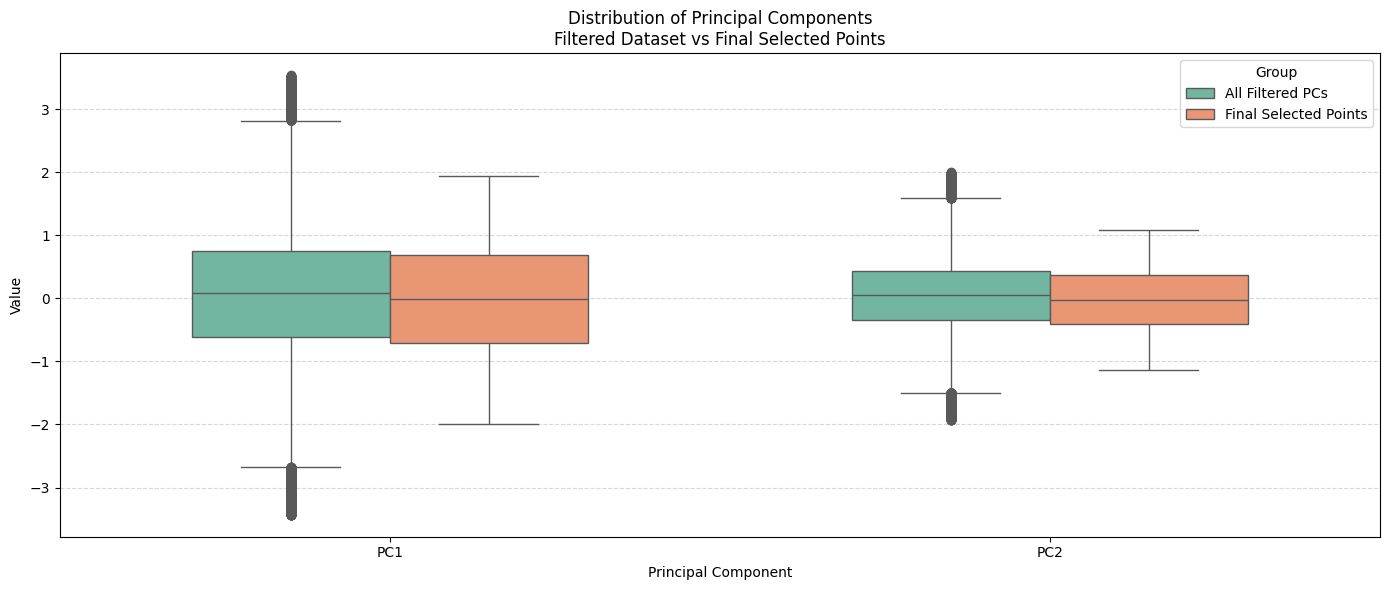

In [ ]:
# @title Boxplot comparing selected data vs. whole data
# Prepare long-format DataFrame for seaborn
box_data = []
num_components = min(filtered_Pcs.shape[1], Var_space_XY[final_result].shape[1])

for i in range(num_components):
    # Add filtered PCs
    box_data.extend([{
        "PC": f"PC{i+1}",
        "Value": val,
        "Group": "All Filtered PCs"
    } for val in filtered_Pcs[:, i]])

    # Add final selected points
    box_data.extend([{
        "PC": f"PC{i+1}",
        "Value": val,
        "Group": "Final Selected Points"
    } for val in Var_space_XY[final_result, i]])

df_box = pd.DataFrame(box_data)

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_box, x="PC", y="Value", hue="Group", palette="Set2", width=0.6)
plt.title("Distribution of Principal Components\nFiltered Dataset vs Final Selected Points")
plt.xlabel("Principal Component")
plt.ylabel("Value")
plt.legend(title="Group", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

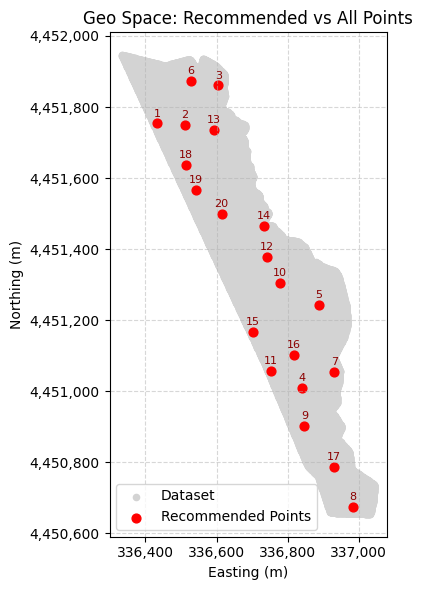

In [ ]:
# @title Display selected points on map
# Clear any previous figures
plt.clf()
plt.figure(figsize=(10, 6))

# Plot full dataset
plt.scatter(df[lon.value], df[lat.value], c='lightgray', s=20, label="Dataset")

# Plot recommended points
plt.scatter(ndf[lon.value], ndf[lat.value], c='red', s=40, label="Recommended Points")

# Annotate recommended points with index (or use FID if preferred)
for i, row in ndf.iterrows():
    label = f"{i+1}"  # or use: str(row['FID'])
    plt.annotate(label, (row[lon.value], row[lat.value]),
                 textcoords="offset points", xytext=(0, 5),
                 ha='center', fontsize=8, color='darkred')

# Update axis labels
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Geo Space: Recommended vs All Points')

# Format axis ticks to be integers (no decimals)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Additional plot settings
plt.legend(loc='best')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from datetime import datetime

# Generate timestamp for filenames and logs
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# File names with timestamp
csv_filename = f"results_{timestamp}.csv"
log_filename = f"run_parameters_{timestamp}.txt"

# --- Build Final Results DataFrame ---
ndf = pd.DataFrame(Geo_space_XY[final_result], columns=[lat.value, lon.value])
ndf['FID'] = df[FID.value].iloc[final_result].values

# Step 1: PCA inverse transform (approximate values)
var_inv = pca.inverse_transform(Var_space_XY[final_result])
var_inv = scaler.inverse_transform(var_inv)

# Step 2: Actual values from the original DataFrame
actual_vars = df.iloc[rows_to_keep].reset_index(drop=True).iloc[final_result]

# Step 3: Add variable columns (actual and approx side-by-side)
selected_var_names = [cb.description for cb in checkboxes if cb.value]

for i, var_name in enumerate(selected_var_names):
    ndf[f"{var_name} (approx)"] = var_inv[:, i]
    ndf[f"{var_name} (actual)"] = actual_vars[var_name].values

# Add index for clarity
ndf.insert(0, "Index", np.arange(1, len(ndf) + 1))

# Save CSV
ndf.to_csv(csv_filename, index=False)

# --- Create Parameters Log ---
with open(log_filename, "w") as f:
    f.write("=== Model Run Parameters Log ===\n\n")
    f.write(f"Run Timestamp: {timestamp}\n\n")

    # Scaling Info
    f.write(f"Scaler Used: {type(scaler).__name__}\n")
    if hasattr(scaler, 'center_'):
        f.write(f"Mean (center_): {np.round(scaler.center_, 4).tolist()}\n")
    if hasattr(scaler, 'scale_'):
        f.write(f"Scale (scale_): {np.round(scaler.scale_, 4).tolist()}\n")
    f.write("\n")

    # PCA Info
    f.write(f"PCA Components: {pca.n_components_}\n")
    f.write(f"Explained Variance Ratio: {np.round(pca.explained_variance_ratio_, 4).tolist()}\n")
    f.write("\n")

    # Distance Scaling Thresholds
    f.write(f"Geo Min: {np.round(geo_min, 4)}\n")
    f.write(f"Geo Max: {np.round(geo_max, 4)}\n")
    f.write(f"Var Min: {np.round(var_min, 4)}\n")
    f.write(f"Var Max: {np.round(var_max, 4)}\n")
    f.write("\n")

    # Weighting
    if 'W' in globals():
        f.write(f"Weight (geo/var tradeoff): W = {W}\n")
    if all(x in globals() for x in ['W1', 'W2', 'W3']):
        f.write(f"Multi-objective weights: W1 = {W1}, W2 = {W2}, W3 = {W3}\n")
    f.write("\n")

    # Combination sampling input summary
    f.write(f"Filtered Indices: {len(filtered_indices)} groups\n")
    f.write(f"Filtered Distances: {len(filtered_distances)} groups\n")
    f.write("\n=== End of Parameters Log ===\n")

# --- Download Both Files ---
files.download(csv_filename)
files.download(log_filename)

# Preview
ndf.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Index,northing,easting,FID,NDVI (approx),NDVI (actual),NDRE (approx),NDRE (actual)
0,1,4.451754e+06,336432.205350,40980,0.802937,0.802937,0.263679,0.263679
1,2,4.451749e+06,336511.208719,42298,0.844381,0.844381,0.224373,0.224373
2,3,4.451861e+06,336605.202070,16811,0.876600,0.876600,0.332201,0.332201
3,4,4.451010e+06,336841.207872,217790,0.916612,0.916612,0.293065,0.293065
4,5,4.451243e+06,336887.203997,163110,0.860434,0.860434,0.278322,0.278322


## ✅ Summary of Improvements – Session: July 17, 2025

### 🚀 Performance Optimization
- Replaced `distance_matrix` and `cdist` with `KDTree.query()` for faster, memory-efficient nearest-neighbor queries.
- Rewrote combination-building logic to avoid list expansion and redundant conversion (`np.fromiter` and `array` used instead).
- Skipped iterations when `DistanceBand` weights were invalid (e.g. contained NaNs).
- Reduced memory load by avoiding full distance matrices unless strictly required for `min()` or `max()` operations.

### 📊 Visualization Enhancements
- Improved boxplot clarity:
  - Color-coded filtered vs selected points.
  - Clear labeling: `PC1`, `PC2`, etc. along with legend entries.
- Updated map plot:
  - Latitude/Longitude replaced with **Easting** and **Northing** labels.
  - Axis ticks now use integer format, no decimals.
  - Annotated selected points with `Index` or `FID` for clarity.

### 🧠 User Experience Enhancements
- Added "Uploading..." → "Done." messaging for file widgets to handle large CSV uploads gracefully.
- Ensured the second file upload (`uploader2`) is optional and non-blocking.
- Prevented multiple copies of uploaded files from accumulating in memory.

### 📁 Output File Features
- Exported CSV includes:
  - `Index` and `FID` columns.
  - Both **approximate (PCA inverse)** and **actual** variable values side-by-side.
- Generated `run_parameters_<timestamp>.txt` includes:
  - Scaler used (`StandardScaler`, etc.) with `.center_` and `.scale_` values.
  - PCA component count and explained variance ratio.
  - Scaling thresholds for geo and variable distances.
  - Weighting parameters (`W`, `W1`, `W2`, `W3`) used in scoring logic.
  - Number of filtered point groups used.
  - Timestamp of execution.

### 🧾 Naming and File Versioning
- All exported files (`results.csv`, `run_parameters.txt`) are now timestamped, e.g.:
  - `results_2025-07-17_17-45-33.csv`
  - `run_parameters_2025-07-17_17-45-33.txt`
- Datetime stamp is also included in the content of the TXT log file.

---

### Future Work – Sampling Optimization

#### 1. Empirical NN Distance Optimization
- Sweep over multiple NN thresholds (e.g., 20–100 m) and evaluate:
  - R² and RMSE on validation data.
  - Moran’s I on residuals.
  - geoMSD to measure spatial spread.
- Select the smallest NN distance that yields near-zero Moran’s I and stable R².

#### 2. Variogram-Based Range Estimation
- Fit a variogram to model residuals and use ~95% of the effective range as NN distance.
- Ensures residual independence while minimizing over-spacing.

#### 3. Heuristic Local Variance Approach
- Compute variance in k-NN neighborhoods for each point.
- Pick NN distance where variance stabilizes (low computational load).
- Especially useful for dense drone or EM38 datasets.

#### 4. Hybrid Validation
- Apply chosen NN distance to full dataset.
- Compare against full pairwise (SRS) method:
  - Spatial spread (geoMSD)
  - Residual autocorrelation (Moran’s I)
  - Predictive accuracy (R², RMSE)
- If comparable, adopt NN approach for permanent RAM savings.

---

### 📊 Summary Table

| Method                     | Estimate of Optimal dₙₙ         | RAM Friendly | Rigor        | Notes                                           |
|---------------------------|----------------------------------|--------------|--------------|------------------------------------------------|
| **Empirical sweep**       | Based on R², Moran’s I           | ⚠️ Moderate  | ✅ Empirical  | Best tradeoff if you can afford small loops    |
| **Variogram (residuals)** | Use 95% of estimated range       | ⚠️ Medium    | ✅ Theoretical| Matches Lesch (2005) approach                  |
| **Heuristic (local var)** | Distance where variance flattens | ✅ Yes        | ⚠️ Approximate| Great for massive datasets with no modeling    |
